In [1]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

In [2]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy
import seaborn as sns

from sklearn import preprocessing
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import QuantileTransformer

In [64]:
train_features = pd.read_csv('train_features.csv')
train_targets_scored = pd.read_csv('train_targets_scored.csv')
train_targets_nonscored = pd.read_csv('train_targets_nonscored.csv')

test_features = pd.read_csv('test_features.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [65]:
GENES = [col for col in train_features.columns if col.startswith('g-')]
CELLS = [col for col in train_features.columns if col.startswith('c-')]

In [6]:
# They are spiky distribution rather than normal distribution.
# Regardless of the train and test, they look be in the same shape.

In [7]:
#train set before using RankGauss

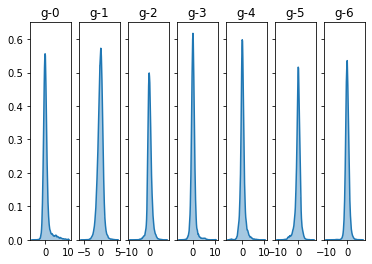

In [8]:
gnum = train_features[GENES].shape[1]
graphs = []

for i in range(0, gnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=771:
            break
        graph = sns.distplot(train_features[GENES].values[:,item], ax=axs[k])
        graph.set_title(f"g-{item}")
        graphs.append(graph)

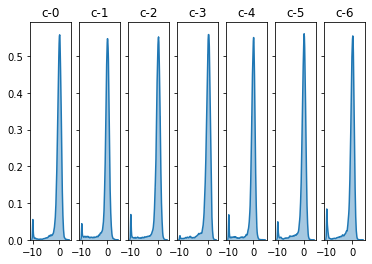

In [9]:
cnum = train_features[CELLS].shape[1]
graphs = []

for i in range(0, cnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=100:
            break
        graph = sns.distplot(train_features[CELLS].values[:,item], ax=axs[k])
        graph.set_title(f"c-{item}")
        graphs.append(graph)

In [10]:
#test set before using RankGauss

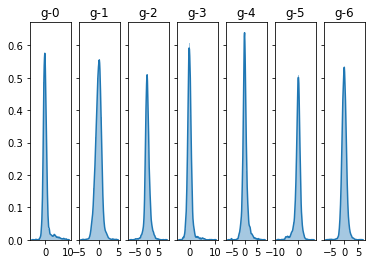

In [11]:
gnum = test_features[GENES].shape[1]
graphs = []

for i in range(0, gnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=771:
            break
        graph = sns.distplot(test_features[GENES].values[:,item], ax=axs[k])
        graph.set_title(f"g-{item}")
        graphs.append(graph)

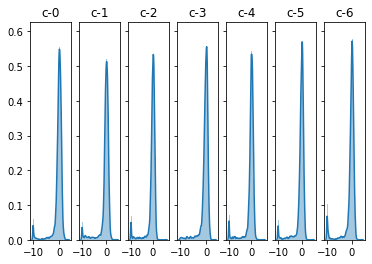

In [12]:
cnum = test_features[CELLS].shape[1]
graphs = []

for i in range(0, cnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=100:
            break
        graph = sns.distplot(test_features[CELLS].values[:,item], ax=axs[k])
        graph.set_title(f"c-{item}")
        graphs.append(graph)

In [13]:
#since the shape of the distribution is close to normal distribution to begin with, 
#we can forced  it to be transformed into a Gaussian distribution.

In [66]:
#RankGauss
#This method transforms the features to follow a uniform or a normal distribution.
#Therefore, for a given feature, this transformation tends to spread out the most frequent values.
#It also reduces the impact of (marginal) outliers: this is therefore a robust preprocessing scheme.

for col in (GENES + CELLS):

    transformer = QuantileTransformer(n_quantiles=100,random_state=0, output_distribution="normal")
    vec_len = len(train_features[col].values)
    vec_len_test = len(test_features[col].values)
    raw_vec = train_features[col].values.reshape(vec_len, 1)
    transformer.fit(raw_vec)
    train_features[col] = transformer.transform(raw_vec).reshape(1, vec_len)[0]
    test_features[col] = transformer.transform(test_features[col].values.reshape(vec_len_test, 1)).reshape(1, vec_len_test)[0]

In [15]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    
seed_everything(seed=42)

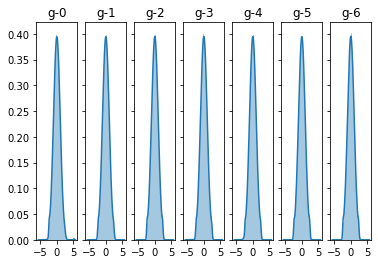

In [16]:
gnum = train_features[GENES].shape[1]
graphs = []

for i in range(0, gnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=771:
            break
        graph = sns.distplot(train_features[GENES].values[:,item], ax=axs[k])
        graph.set_title(f"g-{item}")
        graphs.append(graph)

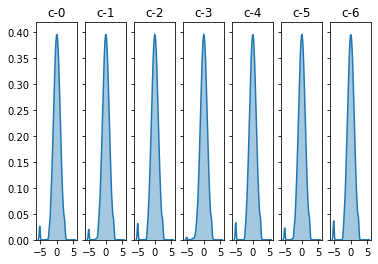

In [17]:
cnum = train_features[CELLS].shape[1]
graphs = []

for i in range(0, cnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=100:
            break
        graph = sns.distplot(train_features[CELLS].values[:,item], ax=axs[k])
        graph.set_title(f"c-{item}")
        graphs.append(graph)

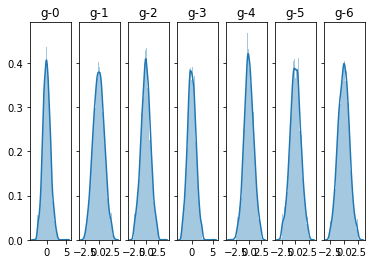

In [18]:
gnum = test_features[GENES].shape[1]
graphs = []

for i in range(0, gnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=771:
            break
        graph = sns.distplot(test_features[GENES].values[:,item], ax=axs[k])
        graph.set_title(f"g-{item}")
        graphs.append(graph)

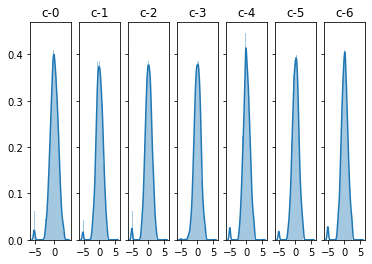

In [19]:
cnum = test_features[CELLS].shape[1]
graphs = []

for i in range(0, cnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=100:
            break
        graph = sns.distplot(test_features[CELLS].values[:,item], ax=axs[k])
        graph.set_title(f"c-{item}")
        graphs.append(graph)

In [20]:
#PCA features + Existing features¶

In [67]:
data = pd.concat([pd.DataFrame(train_features[GENES]), pd.DataFrame(test_features[GENES])])

In [68]:
data.shape

(27796, 772)

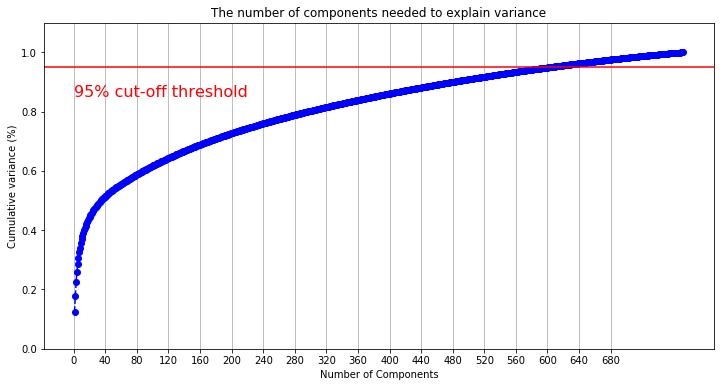

In [69]:
pca = PCA().fit(data)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,6)

fig, ax = plt.subplots()
xi = np.arange(1, 773, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 720, step=40)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

In [70]:
pca_df=pd.DataFrame(xi, columns=['Num_of_comp'])
pca_df['var']=y

In [71]:
pca_df.head()

,Num_of_comp,var
0,1,0.124599
1,2,0.176484
2,3,0.224797
3,4,0.258789
4,5,0.284852


In [74]:
pca_df[pca_df['var']>0.94] # 600:0.948669

,Num_of_comp,var
576,577,0.940182
577,578,0.940558
578,579,0.940934
579,580,0.941309
580,581,0.941684
581,582,0.942057
582,583,0.942430
583,584,0.942803
584,585,0.943175
585,586,0.943546


In [21]:
# GENES
n_comp = 600  #<--Update

data = pd.concat([pd.DataFrame(train_features[GENES]), pd.DataFrame(test_features[GENES])])
data2 = (PCA(n_components=n_comp, random_state=42).fit_transform(data[GENES]))
train2 = data2[:train_features.shape[0]]; test2 = data2[-test_features.shape[0]:]

train2 = pd.DataFrame(train2, columns=[f'pca_G-{i}' for i in range(n_comp)])
test2 = pd.DataFrame(test2, columns=[f'pca_G-{i}' for i in range(n_comp)])

# drop_cols = [f'c-{i}' for i in range(n_comp,len(GENES))]
train_features = pd.concat((train_features, train2), axis=1)
test_features = pd.concat((test_features, test2), axis=1)

In [25]:
[i for i in train_features.columns][876:] # pca_g_0 to pca_g_599

['pca_G-0',
 'pca_G-1',
 'pca_G-2',
 'pca_G-3',
 'pca_G-4',
 'pca_G-5',
 'pca_G-6',
 'pca_G-7',
 'pca_G-8',
 'pca_G-9',
 'pca_G-10',
 'pca_G-11',
 'pca_G-12',
 'pca_G-13',
 'pca_G-14',
 'pca_G-15',
 'pca_G-16',
 'pca_G-17',
 'pca_G-18',
 'pca_G-19',
 'pca_G-20',
 'pca_G-21',
 'pca_G-22',
 'pca_G-23',
 'pca_G-24',
 'pca_G-25',
 'pca_G-26',
 'pca_G-27',
 'pca_G-28',
 'pca_G-29',
 'pca_G-30',
 'pca_G-31',
 'pca_G-32',
 'pca_G-33',
 'pca_G-34',
 'pca_G-35',
 'pca_G-36',
 'pca_G-37',
 'pca_G-38',
 'pca_G-39',
 'pca_G-40',
 'pca_G-41',
 'pca_G-42',
 'pca_G-43',
 'pca_G-44',
 'pca_G-45',
 'pca_G-46',
 'pca_G-47',
 'pca_G-48',
 'pca_G-49',
 'pca_G-50',
 'pca_G-51',
 'pca_G-52',
 'pca_G-53',
 'pca_G-54',
 'pca_G-55',
 'pca_G-56',
 'pca_G-57',
 'pca_G-58',
 'pca_G-59',
 'pca_G-60',
 'pca_G-61',
 'pca_G-62',
 'pca_G-63',
 'pca_G-64',
 'pca_G-65',
 'pca_G-66',
 'pca_G-67',
 'pca_G-68',
 'pca_G-69',
 'pca_G-70',
 'pca_G-71',
 'pca_G-72',
 'pca_G-73',
 'pca_G-74',
 'pca_G-75',
 'pca_G-76',
 'pca_G-7

In [75]:
data = pd.concat([pd.DataFrame(train_features[CELLS]), pd.DataFrame(test_features[CELLS])])

In [76]:
data.shape

(27796, 100)

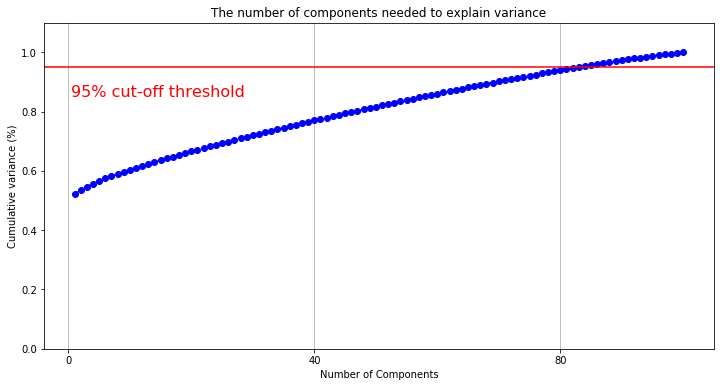

In [83]:
pca = PCA().fit(data)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,6)

fig, ax = plt.subplots()
xi = np.arange(1,101, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 100, step=40)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

In [84]:
pca_df=pd.DataFrame(xi, columns=['Num_of_comp'])
pca_df['var']=y

In [86]:
pca_df[pca_df['Num_of_comp']==50]

,Num_of_comp,var
49,50,0.816925


In [26]:
#CELLS
n_comp = 50  #<--Update

data = pd.concat([pd.DataFrame(train_features[CELLS]), pd.DataFrame(test_features[CELLS])])
data2 = (PCA(n_components=n_comp, random_state=42).fit_transform(data[CELLS]))
train2 = data2[:train_features.shape[0]]; test2 = data2[-test_features.shape[0]:]

train2 = pd.DataFrame(train2, columns=[f'pca_C-{i}' for i in range(n_comp)])
test2 = pd.DataFrame(test2, columns=[f'pca_C-{i}' for i in range(n_comp)])

# drop_cols = [f'c-{i}' for i in range(n_comp,len(CELLS))]
train_features = pd.concat((train_features, train2), axis=1)
test_features = pd.concat((test_features, test2), axis=1)

In [27]:
[i for i in train_features.columns][876:]  # pca_c_0 to pca_c_49

['pca_G-0',
 'pca_G-1',
 'pca_G-2',
 'pca_G-3',
 'pca_G-4',
 'pca_G-5',
 'pca_G-6',
 'pca_G-7',
 'pca_G-8',
 'pca_G-9',
 'pca_G-10',
 'pca_G-11',
 'pca_G-12',
 'pca_G-13',
 'pca_G-14',
 'pca_G-15',
 'pca_G-16',
 'pca_G-17',
 'pca_G-18',
 'pca_G-19',
 'pca_G-20',
 'pca_G-21',
 'pca_G-22',
 'pca_G-23',
 'pca_G-24',
 'pca_G-25',
 'pca_G-26',
 'pca_G-27',
 'pca_G-28',
 'pca_G-29',
 'pca_G-30',
 'pca_G-31',
 'pca_G-32',
 'pca_G-33',
 'pca_G-34',
 'pca_G-35',
 'pca_G-36',
 'pca_G-37',
 'pca_G-38',
 'pca_G-39',
 'pca_G-40',
 'pca_G-41',
 'pca_G-42',
 'pca_G-43',
 'pca_G-44',
 'pca_G-45',
 'pca_G-46',
 'pca_G-47',
 'pca_G-48',
 'pca_G-49',
 'pca_G-50',
 'pca_G-51',
 'pca_G-52',
 'pca_G-53',
 'pca_G-54',
 'pca_G-55',
 'pca_G-56',
 'pca_G-57',
 'pca_G-58',
 'pca_G-59',
 'pca_G-60',
 'pca_G-61',
 'pca_G-62',
 'pca_G-63',
 'pca_G-64',
 'pca_G-65',
 'pca_G-66',
 'pca_G-67',
 'pca_G-68',
 'pca_G-69',
 'pca_G-70',
 'pca_G-71',
 'pca_G-72',
 'pca_G-73',
 'pca_G-74',
 'pca_G-75',
 'pca_G-76',
 'pca_G-7

In [28]:
train_features.shape

(23814, 1526)

In [29]:
#feature Selection using Variance Encoding

In [30]:
from sklearn.feature_selection import VarianceThreshold


var_thresh = VarianceThreshold(0.8)  #<-- Update
data = train_features.append(test_features)
data_transformed = var_thresh.fit_transform(data.iloc[:, 4:])

train_features_transformed = data_transformed[ : train_features.shape[0]]
test_features_transformed = data_transformed[-test_features.shape[0] : ]


train_features = pd.DataFrame(train_features[['sig_id','cp_type','cp_time','cp_dose']].values.reshape(-1, 4),\
                              columns=['sig_id','cp_type','cp_time','cp_dose'])

train_features = pd.concat([train_features, pd.DataFrame(train_features_transformed)], axis=1)


test_features = pd.DataFrame(test_features[['sig_id','cp_type','cp_time','cp_dose']].values.reshape(-1, 4),\
                             columns=['sig_id','cp_type','cp_time','cp_dose'])

test_features = pd.concat([test_features, pd.DataFrame(test_features_transformed)], axis=1)

train_features.shape

(23814, 1040)

In [31]:
train = train_features.merge(train_targets_scored, on='sig_id')
train = train[train['cp_type']!='ctl_vehicle'].reset_index(drop=True)
test = test_features[test_features['cp_type']!='ctl_vehicle'].reset_index(drop=True)

target = train[train_targets_scored.columns]

In [32]:
train = train.drop('cp_type', axis=1)
test = test.drop('cp_type', axis=1)

In [33]:
train.head()

,sig_id,cp_time,cp_dose,0,1,2,3,4,5,6,...,tropomyosin_receptor_kinase_inhibitor,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor
0,id_000644bb2,24,D1,1.134849,0.907687,-0.416385,-0.966814,-0.254723,-1.017473,-1.364787,...,0,0,0,0,0,0,0,0,0,0
1,id_000779bfc,72,D1,0.119282,0.681738,0.272399,0.080113,1.205169,0.686517,0.313396,...,0,0,0,0,0,0,0,0,0,0
2,id_000a6266a,48,D1,0.779973,0.946463,1.425350,-0.132928,-0.006122,1.492493,0.235577,...,0,0,0,0,0,0,0,0,0,0
3,id_0015fd391,48,D1,-0.734910,-0.274641,-0.438509,0.759097,2.346330,-0.858153,-2.288417,...,0,0,0,0,0,0,0,0,0,0
4,id_001626bd3,72,D2,-0.452718,-0.477513,0.972316,0.970731,1.463427,-0.869555,-0.375501,...,0,0,0,0,0,0,0,0,0,0


In [34]:
target_cols = target.drop('sig_id', axis=1).columns.values.tolist()

In [35]:
len(target_cols)

206

In [36]:
#CV folds

In [37]:
folds = train.copy()

mskf = MultilabelStratifiedKFold(n_splits=7)

for f, (t_idx, v_idx) in enumerate(mskf.split(X=train, y=target)):
    folds.loc[v_idx, 'kfold'] = int(f)

folds['kfold'] = folds['kfold'].astype(int)
folds

,sig_id,cp_time,cp_dose,0,1,2,3,4,5,6,...,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor,kfold
0,id_000644bb2,24,D1,1.134849,0.907687,-0.416385,-0.966814,-0.254723,-1.017473,-1.364787,...,0,0,0,0,0,0,0,0,0,5
1,id_000779bfc,72,D1,0.119282,0.681738,0.272399,0.080113,1.205169,0.686517,0.313396,...,0,0,0,0,0,0,0,0,0,0
2,id_000a6266a,48,D1,0.779973,0.946463,1.425350,-0.132928,-0.006122,1.492493,0.235577,...,0,0,0,0,0,0,0,0,0,6
3,id_0015fd391,48,D1,-0.734910,-0.274641,-0.438509,0.759097,2.346330,-0.858153,-2.288417,...,0,0,0,0,0,0,0,0,0,0
4,id_001626bd3,72,D2,-0.452718,-0.477513,0.972316,0.970731,1.463427,-0.869555,-0.375501,...,0,0,0,0,0,0,0,0,0,4
5,id_001762a82,24,D1,-0.880697,0.508160,-1.416109,0.335123,1.391083,0.686071,0.080179,...,0,0,0,0,0,0,0,0,0,2
6,id_001bd861f,24,D2,1.500212,2.153865,-1.834969,2.477495,-2.291874,-2.206654,2.427419,...,0,0,0,0,0,0,0,0,0,6
7,id_0020d0484,48,D1,0.372970,0.841985,-0.264910,2.061578,0.926238,0.763292,-0.354035,...,0,0,0,0,0,0,0,0,0,2
8,id_00224bf20,48,D1,-0.417590,0.902769,-0.428691,-0.231764,-0.921987,-0.678041,-1.021121,...,0,0,0,0,0,0,0,0,0,0
9,id_0023f063e,48,D2,-0.077234,0.453862,-0.799807,-0.412610,0.012988,-1.339064,-0.295002,...,0,0,0,0,0,0,0,0,0,5


In [38]:
print(train.shape)
print(folds.shape)
print(test.shape)
print(target.shape)
print(sample_submission.shape)

(21948, 1245)
(21948, 1246)
(3624, 1039)
(21948, 207)
(3982, 207)


In [39]:
#Dataset Classes
class MoADataset:
    def __init__(self, features, targets):
        self.features = features
        self.targets = targets
        
    def __len__(self):
        return (self.features.shape[0])
    
    def __getitem__(self, idx):
        dct = {
            'x' : torch.tensor(self.features[idx, :], dtype=torch.float),
            'y' : torch.tensor(self.targets[idx, :], dtype=torch.float)            
        }
        return dct
    
class TestDataset:
    def __init__(self, features):
        self.features = features
        
    def __len__(self):
        return (self.features.shape[0])
    
    def __getitem__(self, idx):
        dct = {
            'x' : torch.tensor(self.features[idx, :], dtype=torch.float)
        }
        return dct
    

In [40]:
def train_fn(model, optimizer, scheduler, loss_fn, dataloader, device):
    model.train()
    final_loss = 0
    
    for data in dataloader:
        optimizer.zero_grad()
        inputs, targets = data['x'].to(device), data['y'].to(device)
#         print(inputs.shape)
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        final_loss += loss.item()
        
    final_loss /= len(dataloader)
    
    return final_loss


def valid_fn(model, loss_fn, dataloader, device):
    model.eval()
    final_loss = 0
    valid_preds = []
    
    for data in dataloader:
        inputs, targets = data['x'].to(device), data['y'].to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        
        final_loss += loss.item()
        valid_preds.append(outputs.sigmoid().detach().cpu().numpy())
        
    final_loss /= len(dataloader)
    valid_preds = np.concatenate(valid_preds)
    
    return final_loss, valid_preds

def inference_fn(model, dataloader, device):
    model.eval()
    preds = []
    
    for data in dataloader:
        inputs = data['x'].to(device)

        with torch.no_grad():
            outputs = model(inputs)
        
        preds.append(outputs.sigmoid().detach().cpu().numpy())
        
    preds = np.concatenate(preds)
    
    return preds

In [41]:
class Model(nn.Module):      # <-- Update
    def __init__(self, num_features, num_targets, hidden_size):
        super(Model, self).__init__()
        self.batch_norm1 = nn.BatchNorm1d(num_features)
        self.dense1 = nn.utils.weight_norm(nn.Linear(num_features, hidden_size))
        
        self.batch_norm2 = nn.BatchNorm1d(hidden_size)
        self.dropout2 = nn.Dropout(0.4)
        self.dense2 = nn.utils.weight_norm(nn.Linear(hidden_size, hidden_size))
        
        self.batch_norm3 = nn.BatchNorm1d(hidden_size)
        self.dropout3 = nn.Dropout(0.4)
        self.dense3 = nn.utils.weight_norm(nn.Linear(hidden_size, num_targets))
    
    def forward(self, x):
        x = self.batch_norm1(x)
        x = F.relu(self.dense1(x))
        
        x = self.batch_norm2(x)
        x = self.dropout2(x)
        x = F.relu(self.dense2(x))
        
        x = self.batch_norm3(x)
        x = self.dropout3(x)
        x = self.dense3(x)
        
        return x

In [42]:
def process_data(data):
    data = pd.get_dummies(data, columns=['cp_time','cp_dose'])
    return data

In [43]:
feature_cols = [c for c in process_data(folds).columns if c not in target_cols]
feature_cols = [c for c in feature_cols if c not in ['kfold','sig_id']]
len(feature_cols)

1041

In [44]:
DEVICE = ('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 25
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
NFOLDS = 7              #<-- Update
EARLY_STOPPING_STEPS = 10
EARLY_STOP = False

num_features=len(feature_cols)
num_targets=len(target_cols)
hidden_size=2048

In [88]:
21948/7/128*25

612.3883928571429

In [45]:
def run_training(fold, seed):
    
    seed_everything(seed)
    
    train = process_data(folds)
    test_ = process_data(test)
    
    trn_idx = train[train['kfold'] != fold].index
    val_idx = train[train['kfold'] == fold].index
    
    train_df = train[train['kfold'] != fold].reset_index(drop=True)
    valid_df = train[train['kfold'] == fold].reset_index(drop=True)
    
    x_train, y_train  = train_df[feature_cols].values, train_df[target_cols].values
    x_valid, y_valid =  valid_df[feature_cols].values, valid_df[target_cols].values
    
    train_dataset = MoADataset(x_train, y_train)
    valid_dataset = MoADataset(x_valid, y_valid)
    trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = Model(
        num_features=num_features,
        num_targets=num_targets,
        hidden_size=hidden_size,
    )
    
    model.to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer=optimizer, pct_start=0.1, div_factor=1e3, 
                                              max_lr=1e-2, epochs=EPOCHS, steps_per_epoch=len(trainloader))
    
    loss_fn = nn.BCEWithLogitsLoss()
    
    early_stopping_steps = EARLY_STOPPING_STEPS
    early_step = 0
    
    oof = np.zeros((len(train), target.iloc[:, 1:].shape[1]))
    best_loss = np.inf
    
    for epoch in range(EPOCHS):
        
        train_loss = train_fn(model, optimizer,scheduler, loss_fn, trainloader, DEVICE)
        print(f"FOLD: {fold}, EPOCH: {epoch}, train_loss: {train_loss}")
        valid_loss, valid_preds = valid_fn(model, loss_fn, validloader, DEVICE)
        print(f"FOLD: {fold}, EPOCH: {epoch}, valid_loss: {valid_loss}")
        
        if valid_loss < best_loss:
            
            best_loss = valid_loss
            oof[val_idx] = valid_preds
            torch.save(model.state_dict(), f"FOLD{fold}_.pth")
        
        elif(EARLY_STOP == True):
            
            early_step += 1
            if (early_step >= early_stopping_steps):
                break
            
    
    #--------------------- PREDICTION---------------------
    x_test = test_[feature_cols].values
    testdataset = TestDataset(x_test)
    testloader = torch.utils.data.DataLoader(testdataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = Model(
        num_features=num_features,
        num_targets=num_targets,
        hidden_size=hidden_size,

    )
    
    model.load_state_dict(torch.load(f"FOLD{fold}_.pth"))
    model.to(DEVICE)
    
    predictions = np.zeros((len(test_), target.iloc[:, 1:].shape[1]))
    predictions = inference_fn(model, testloader, DEVICE)
    
    return oof, predictions

In [46]:
def run_k_fold(NFOLDS, seed):
    oof = np.zeros((len(train), len(target_cols)))
    predictions = np.zeros((len(test), len(target_cols)))
    
    for fold in range(NFOLDS):
        oof_, pred_ = run_training(fold, seed)
        
        predictions += pred_ / NFOLDS
        oof += oof_
        
    return oof, predictions

In [47]:
# Averaging on multiple SEEDS

SEED = [0, 1, 2, 3 ,4, 5 ,6]  #<-- Update
oof = np.zeros((len(train), len(target_cols)))
predictions = np.zeros((len(test), len(target_cols)))

for seed in SEED:
    
    oof_, predictions_ = run_k_fold(NFOLDS, seed)
    oof += oof_ / len(SEED)
    predictions += predictions_ / len(SEED)

train[target_cols] = oof
test[target_cols] = predictions

FOLD: 0, EPOCH: 0, train_loss: 0.4802180748483559
FOLD: 0, EPOCH: 0, valid_loss: 0.02375018946826458
FOLD: 0, EPOCH: 1, train_loss: 0.0212061298491598
FOLD: 0, EPOCH: 1, valid_loss: 0.019269535467028618
FOLD: 0, EPOCH: 2, train_loss: 0.018985056147283436
FOLD: 0, EPOCH: 2, valid_loss: 0.018366319462656974
FOLD: 0, EPOCH: 3, train_loss: 0.017668615589488526
FOLD: 0, EPOCH: 3, valid_loss: 0.01746678341180086
FOLD: 0, EPOCH: 4, train_loss: 0.017116840802082398
FOLD: 0, EPOCH: 4, valid_loss: 0.01704349409788847
FOLD: 0, EPOCH: 5, train_loss: 0.016889951331224166
FOLD: 0, EPOCH: 5, valid_loss: 0.017180062420666217
FOLD: 0, EPOCH: 6, train_loss: 0.01693459622384537
FOLD: 0, EPOCH: 6, valid_loss: 0.01732356209307909
FOLD: 0, EPOCH: 7, train_loss: 0.017016751279889726
FOLD: 0, EPOCH: 7, valid_loss: 0.017113518305122852
FOLD: 0, EPOCH: 8, train_loss: 0.017017370976862452
FOLD: 0, EPOCH: 8, valid_loss: 0.017126936577260495
FOLD: 0, EPOCH: 9, train_loss: 0.017031758656205775
FOLD: 0, EPOCH: 9, va

FOLD: 3, EPOCH: 3, valid_loss: 0.01733232129365206
FOLD: 3, EPOCH: 4, train_loss: 0.0170687514287578
FOLD: 3, EPOCH: 4, valid_loss: 0.01722906231880188
FOLD: 3, EPOCH: 5, train_loss: 0.016908421757675353
FOLD: 3, EPOCH: 5, valid_loss: 0.017100546807050705
FOLD: 3, EPOCH: 6, train_loss: 0.01687396687715232
FOLD: 3, EPOCH: 6, valid_loss: 0.01708494246006012
FOLD: 3, EPOCH: 7, train_loss: 0.016952558699361728
FOLD: 3, EPOCH: 7, valid_loss: 0.017285500839352607
FOLD: 3, EPOCH: 8, train_loss: 0.017001087036059827
FOLD: 3, EPOCH: 8, valid_loss: 0.017337651140987873
FOLD: 3, EPOCH: 9, train_loss: 0.017001775321455633
FOLD: 3, EPOCH: 9, valid_loss: 0.017295672073960305
FOLD: 3, EPOCH: 10, train_loss: 0.016986246170083277
FOLD: 3, EPOCH: 10, valid_loss: 0.017182156369090082
FOLD: 3, EPOCH: 11, train_loss: 0.016974422383774706
FOLD: 3, EPOCH: 11, valid_loss: 0.017211239002645016
FOLD: 3, EPOCH: 12, train_loss: 0.016866534961020054
FOLD: 3, EPOCH: 12, valid_loss: 0.0168887622654438
FOLD: 3, EPOCH

FOLD: 6, EPOCH: 7, train_loss: 0.01698722023846341
FOLD: 6, EPOCH: 7, valid_loss: 0.016990506686270238
FOLD: 6, EPOCH: 8, train_loss: 0.017014654486307075
FOLD: 6, EPOCH: 8, valid_loss: 0.017092342488467693
FOLD: 6, EPOCH: 9, train_loss: 0.017055023493257916
FOLD: 6, EPOCH: 9, valid_loss: 0.01695315320044756
FOLD: 6, EPOCH: 10, train_loss: 0.017034557381910936
FOLD: 6, EPOCH: 10, valid_loss: 0.017009598575532435
FOLD: 6, EPOCH: 11, train_loss: 0.017003122387694664
FOLD: 6, EPOCH: 11, valid_loss: 0.017049107439815997
FOLD: 6, EPOCH: 12, train_loss: 0.01694239747590151
FOLD: 6, EPOCH: 12, valid_loss: 0.016929006539285182
FOLD: 6, EPOCH: 13, train_loss: 0.016850102128980516
FOLD: 6, EPOCH: 13, valid_loss: 0.01687507126480341
FOLD: 6, EPOCH: 14, train_loss: 0.01673537273542816
FOLD: 6, EPOCH: 14, valid_loss: 0.016680090241134166
FOLD: 6, EPOCH: 15, train_loss: 0.016611182073853453
FOLD: 6, EPOCH: 15, valid_loss: 0.016528967060148714
FOLD: 6, EPOCH: 16, train_loss: 0.01641493125305492
FOLD:

FOLD: 2, EPOCH: 11, train_loss: 0.016986281218222616
FOLD: 2, EPOCH: 11, valid_loss: 0.017167652733623983
FOLD: 2, EPOCH: 12, train_loss: 0.016935438234485737
FOLD: 2, EPOCH: 12, valid_loss: 0.017032601609826087
FOLD: 2, EPOCH: 13, train_loss: 0.016826065377566684
FOLD: 2, EPOCH: 13, valid_loss: 0.01676395572721958
FOLD: 2, EPOCH: 14, train_loss: 0.016634189739164446
FOLD: 2, EPOCH: 14, valid_loss: 0.016683361120522024
FOLD: 2, EPOCH: 15, train_loss: 0.01651555799632048
FOLD: 2, EPOCH: 15, valid_loss: 0.016667623221874237
FOLD: 2, EPOCH: 16, train_loss: 0.016393795653822877
FOLD: 2, EPOCH: 16, valid_loss: 0.016616511829197406
FOLD: 2, EPOCH: 17, train_loss: 0.016137585956223156
FOLD: 2, EPOCH: 17, valid_loss: 0.016488033160567284
FOLD: 2, EPOCH: 18, train_loss: 0.015892276458036737
FOLD: 2, EPOCH: 18, valid_loss: 0.01622229427099228
FOLD: 2, EPOCH: 19, train_loss: 0.015553721062028084
FOLD: 2, EPOCH: 19, valid_loss: 0.016211207732558252
FOLD: 2, EPOCH: 20, train_loss: 0.015150084857176

FOLD: 5, EPOCH: 14, valid_loss: 0.016835509203374385
FOLD: 5, EPOCH: 15, train_loss: 0.01653040792210167
FOLD: 5, EPOCH: 15, valid_loss: 0.016842736080288887
FOLD: 5, EPOCH: 16, train_loss: 0.016348999335753674
FOLD: 5, EPOCH: 16, valid_loss: 0.016607578322291375
FOLD: 5, EPOCH: 17, train_loss: 0.01608659831971741
FOLD: 5, EPOCH: 17, valid_loss: 0.016562701985239982
FOLD: 5, EPOCH: 18, train_loss: 0.01583108429473882
FOLD: 5, EPOCH: 18, valid_loss: 0.016341720893979072
FOLD: 5, EPOCH: 19, train_loss: 0.015511097836301845
FOLD: 5, EPOCH: 19, valid_loss: 0.016293083280324937
FOLD: 5, EPOCH: 20, train_loss: 0.015126856335369096
FOLD: 5, EPOCH: 20, valid_loss: 0.016121231503784656
FOLD: 5, EPOCH: 21, train_loss: 0.014727402421436747
FOLD: 5, EPOCH: 21, valid_loss: 0.01601056344807148
FOLD: 5, EPOCH: 22, train_loss: 0.014282168573414793
FOLD: 5, EPOCH: 22, valid_loss: 0.015947871282696723
FOLD: 5, EPOCH: 23, train_loss: 0.013947848762784685
FOLD: 5, EPOCH: 23, valid_loss: 0.0159699201583862

...

FOLD: 2, EPOCH: 19, train_loss: 0.015584312525077337
FOLD: 2, EPOCH: 19, valid_loss: 0.01614954948425293
FOLD: 2, EPOCH: 20, train_loss: 0.01523606724352861
FOLD: 2, EPOCH: 20, valid_loss: 0.015983592346310617
FOLD: 2, EPOCH: 21, train_loss: 0.014785906521692163
FOLD: 2, EPOCH: 21, valid_loss: 0.015890026316046715
FOLD: 2, EPOCH: 22, train_loss: 0.014384851784629076
FOLD: 2, EPOCH: 22, valid_loss: 0.015869591534137726
FOLD: 2, EPOCH: 23, train_loss: 0.014088444595484912
FOLD: 2, EPOCH: 23, valid_loss: 0.01580193229019642
FOLD: 2, EPOCH: 24, train_loss: 0.013956090562096258
FOLD: 2, EPOCH: 24, valid_loss: 0.015826053507626055
FOLD: 3, EPOCH: 0, train_loss: 0.4808372969859514
FOLD: 3, EPOCH: 0, valid_loss: 0.02562276095151901
FOLD: 3, EPOCH: 1, train_loss: 0.021278445944696866
FOLD: 3, EPOCH: 1, valid_loss: 0.019197789207100868
FOLD: 3, EPOCH: 2, train_loss: 0.019004829329292792
FOLD: 3, EPOCH: 2, valid_loss: 0.01811673641204834
FOLD: 3, EPOCH: 3, train_loss: 0.017671992717196747
FOLD: 3

FOLD: 5, EPOCH: 22, valid_loss: 0.015953639000654222
FOLD: 5, EPOCH: 23, train_loss: 0.013965817611841928
FOLD: 5, EPOCH: 23, valid_loss: 0.01593236453831196
FOLD: 5, EPOCH: 24, train_loss: 0.013802969346747917
FOLD: 5, EPOCH: 24, valid_loss: 0.015936824083328246
FOLD: 6, EPOCH: 0, train_loss: 0.48021314395781683
FOLD: 6, EPOCH: 0, valid_loss: 0.023612830489873886
FOLD: 6, EPOCH: 1, train_loss: 0.020927127374678244
FOLD: 6, EPOCH: 1, valid_loss: 0.01870960049331188
FOLD: 6, EPOCH: 2, train_loss: 0.018895121677746984
FOLD: 6, EPOCH: 2, valid_loss: 0.018321190141141416
FOLD: 6, EPOCH: 3, train_loss: 0.017668225181599457
FOLD: 6, EPOCH: 3, valid_loss: 0.0174255458638072
FOLD: 6, EPOCH: 4, train_loss: 0.017106598623248995
FOLD: 6, EPOCH: 4, valid_loss: 0.01698730457574129
FOLD: 6, EPOCH: 5, train_loss: 0.016915848846135496
FOLD: 6, EPOCH: 5, valid_loss: 0.016929322481155397
FOLD: 6, EPOCH: 6, train_loss: 0.016966639897551667
FOLD: 6, EPOCH: 6, valid_loss: 0.017184055373072625
FOLD: 6, EPOC

FOLD: 2, EPOCH: 1, train_loss: 0.021112311048572568
FOLD: 2, EPOCH: 1, valid_loss: 0.019464125372469426
FOLD: 2, EPOCH: 2, train_loss: 0.019078383615025046
FOLD: 2, EPOCH: 2, valid_loss: 0.01802228294312954
FOLD: 2, EPOCH: 3, train_loss: 0.017662345171988416
FOLD: 2, EPOCH: 3, valid_loss: 0.017326808273792266
FOLD: 2, EPOCH: 4, train_loss: 0.01700399136867653
FOLD: 2, EPOCH: 4, valid_loss: 0.017380154505372048
FOLD: 2, EPOCH: 5, train_loss: 0.01687935274727896
FOLD: 2, EPOCH: 5, valid_loss: 0.017200481928884983
FOLD: 2, EPOCH: 6, train_loss: 0.016831841813970586
FOLD: 2, EPOCH: 6, valid_loss: 0.017044946663081647
FOLD: 2, EPOCH: 7, train_loss: 0.017008009974901775
FOLD: 2, EPOCH: 7, valid_loss: 0.017323403097689153
FOLD: 2, EPOCH: 8, train_loss: 0.01701014692939463
FOLD: 2, EPOCH: 8, valid_loss: 0.01730438232421875
FOLD: 2, EPOCH: 9, train_loss: 0.01696955714197386
FOLD: 2, EPOCH: 9, valid_loss: 0.01709595389664173
FOLD: 2, EPOCH: 10, train_loss: 0.016987508435283794
FOLD: 2, EPOCH: 10

FOLD: 5, EPOCH: 4, valid_loss: 0.01718144729733467
FOLD: 5, EPOCH: 5, train_loss: 0.016950409929109674
FOLD: 5, EPOCH: 5, valid_loss: 0.017164265364408494
FOLD: 5, EPOCH: 6, train_loss: 0.016916169170416943
FOLD: 5, EPOCH: 6, valid_loss: 0.017240421622991563
FOLD: 5, EPOCH: 7, train_loss: 0.017006901834084064
FOLD: 5, EPOCH: 7, valid_loss: 0.017306781895458697
FOLD: 5, EPOCH: 8, train_loss: 0.017015176926593798
FOLD: 5, EPOCH: 8, valid_loss: 0.017233007550239564
FOLD: 5, EPOCH: 9, train_loss: 0.017024102734819968
FOLD: 5, EPOCH: 9, valid_loss: 0.01725360967218876
FOLD: 5, EPOCH: 10, train_loss: 0.016986025262902788
FOLD: 5, EPOCH: 10, valid_loss: 0.01700175113976002
FOLD: 5, EPOCH: 11, train_loss: 0.016907243210138107
FOLD: 5, EPOCH: 11, valid_loss: 0.017373216077685355
FOLD: 5, EPOCH: 12, train_loss: 0.01696853727406385
FOLD: 5, EPOCH: 12, valid_loss: 0.017216093838214874
FOLD: 5, EPOCH: 13, train_loss: 0.01674026338269516
FOLD: 5, EPOCH: 13, valid_loss: 0.01713005155324936
FOLD: 5, E

KeyError: "None of [Index(['5-alpha_reductase_inhibitor', '11-beta-hsd1_inhibitor',\n       'acat_inhibitor', 'acetylcholine_receptor_agonist',\n       'acetylcholine_receptor_antagonist', 'acetylcholinesterase_inhibitor',\n       'adenosine_receptor_agonist', 'adenosine_receptor_antagonist',\n       'adenylyl_cyclase_activator', 'adrenergic_receptor_agonist',\n       ...\n       'tropomyosin_receptor_kinase_inhibitor', 'trpv_agonist',\n       'trpv_antagonist', 'tubulin_inhibitor', 'tyrosine_kinase_inhibitor',\n       'ubiquitin_specific_protease_inhibitor', 'vegfr_inhibitor', 'vitamin_b',\n       'vitamin_d_receptor_agonist', 'wnt_inhibitor'],\n      dtype='object', length=206)] are in the [columns]"

In [51]:
train[target_cols] = oof

In [49]:
len(target_cols)

206

In [48]:
predictions.shape

(3624, 206)

In [55]:
train.shape

(21948, 1245)

In [56]:
test.shape

(3624, 1039)

In [60]:
for i in range(len(target_cols)):
    fea=target_cols[i]
    test[fea]=predictions[:,i]

In [61]:
test.shape

(3624, 1245)

In [62]:
test.head()

,sig_id,cp_time,cp_dose,0,1,2,3,4,5,6,...,tropomyosin_receptor_kinase_inhibitor,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor
0,id_0004d9e33,24,D1,-0.780778,0.261727,-0.779608,0.640179,1.532089,-0.191112,-0.289497,...,0.000826,0.002578,0.005822,0.000782,0.000684,0.000543,0.000561,0.001845,0.008957,0.001474
1,id_001897cda,72,D1,-0.245017,0.417006,1.168949,-0.708951,-0.517363,-0.390555,-2.213382,...,0.000797,0.000943,0.005716,0.000285,0.010227,0.000372,0.007980,0.001099,0.000605,0.002626
2,id_00276f245,24,D2,0.628172,0.359716,0.366921,0.616193,-0.839624,-1.149929,0.763103,...,0.000523,0.001088,0.003092,0.010535,0.005458,0.000517,0.002010,0.002160,0.000218,0.002068
3,id_0027f1083,48,D1,-0.562820,-1.449243,1.658487,0.302608,-0.840776,0.000017,0.657583,...,0.000659,0.000399,0.002592,0.000863,0.001215,0.000573,0.001414,0.001458,0.000120,0.001617
4,id_006fc47b8,48,D2,0.490815,0.901390,-1.024895,-2.095041,0.741717,-0.449766,-0.637682,...,0.000637,0.000829,0.002192,0.003738,0.001081,0.000277,0.000420,0.001770,0.000101,0.001169


In [54]:
valid_results = train_targets_scored.drop(columns=target_cols).merge(train[['sig_id']+target_cols], on='sig_id', how='left').fillna(0)


y_true = train_targets_scored[target_cols].values
y_pred = valid_results[target_cols].values

score = 0
for i in range(len(target_cols)):
    score_ = log_loss(y_true[:, i], y_pred[:, i])
    score += score_ / target.shape[1]
    
print("CV log_loss: ", score)

CV log_loss:  0.014458230599627767


In [63]:
sub = sample_submission.drop(columns=target_cols).merge(test[['sig_id']+target_cols], on='sig_id', how='left').fillna(0)
sub.to_csv('sub_pytorch_7folds.csv', index=False)